# A/B Testing in ML

A/B testing in machine learning (ML) is a key technique for evaluating the real-world impact of different models, features, or strategies. 

-------

A/B testing (also called split testing) is an experimental setup where two versions (A and B) are compared to determine which one performs better on a specific metric. In ML, this usually involves:

A: The current (baseline) ML model.

B: A new or improved ML model.
____

How It Works

1. **Random Split**: Traffic (users, requests, data points) is randomly split between the two models:
50% go to Model A
50% go to Model B

2. **Live Deployment**: Both models make predictions in parallel in a production or near-production environment.

3. **Metric Collection**: Key business or user-centric metrics are tracked — e.g., click-through rate, conversion rate, user retention, revenue, or precision/recall.

4. **Statistical Testing**: After running the test long enough to gather sufficient data, a statistical hypothesis test (e.g., t-test, z-test, chi-square) determines if the observed difference is significant.
____

A/B Testing vs. Offline Metrics

Offline evaluation (cross-validation, holdout set) measures model accuracy on historical data.

A/B testing measures how the model performs in production, capturing user behavior, latency.
___

# Task

Its a simple A/B test simulation, where we compare two ML models (A and B) on a binary classification task using synthetic conversion data (e.g., user clicked vs. not clicked). We'll simulate traffic, generate outcomes, and perform a statistical test to determine if one model is significantly better.

###  A/B Test Simulation

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# Set seed for reproducibility
np.random.seed(42)

# Simulate data
n_users = 100000

# Model A (baseline) - conversion rate = 15%
model_a_users = n_users // 2
model_a_conversions = np.random.binomial(1, 0.15, model_a_users)

# Model B (variant) - conversion rate = 12%
model_b_users = n_users // 2
model_b_conversions = np.random.binomial(1, 0.12, model_b_users)
print("model_a_users", model_a_users)
print("model_b_users", model_b_users)

model_a_users 50000
model_b_users 50000


In [2]:

# Conversion rates
cr_a = np.mean(model_a_conversions)
cr_b = np.mean(model_b_conversions)

print(f"Model A Conversion Rate: {cr_a:.4f}")
print(f"Model B Conversion Rate: {cr_b:.4f}")


Model A Conversion Rate: 0.1491
Model B Conversion Rate: 0.1172


In [3]:

# Perform two-proportion z-test
count = np.array([model_a_conversions.sum(), model_b_conversions.sum()])
# Define nobs as the number of observations for each group
nobs = np.array([model_a_users, model_b_users])

# Perform two-proportion z-test
stat, pval = proportions_ztest(count, nobs)

print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")


Z-statistic: 14.8444
P-value: 0.0000


In [4]:

# Result interpretation
alpha = 0.05
if pval < alpha:
    print("🔍 Statistically significant difference! Model B is better.")
else:
    print("⚠️ No significant difference detected.")


🔍 Statistically significant difference! Model B is better.


### Visualize Conversion Rates

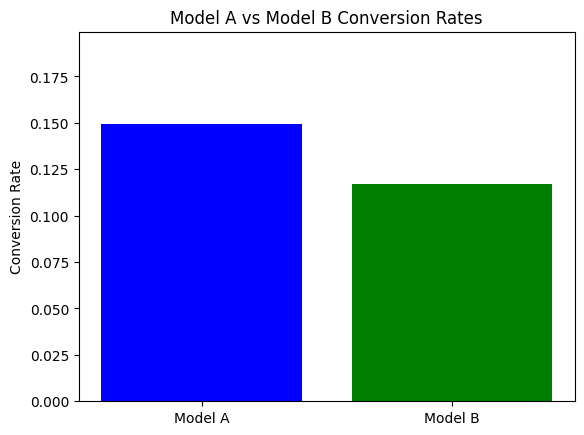

In [5]:
# Bar plot
plt.bar(['Model A', 'Model B'], [cr_a, cr_b], color=['blue', 'green'])
plt.ylabel('Conversion Rate')
plt.title('Model A vs Model B Conversion Rates')
plt.ylim(0, max(cr_a, cr_b) + 0.05)
plt.show()


### Inference 

**Key Points**

We simulate 10,000 users split equally between Model A and B.

We assume Model B has a slightly higher true conversion rate (12% vs 10%).

We run a two-proportion Z-test to see if the difference is statistically significant.

----

#### Further Three directions to improve 

1. Simulating over time (e.g., daily batches)

2. Bayesian A/B testing instead of frequentist

3. Multi-metric evaluation or uplift modeling

---

Simulating Over Time (Daily Batches)

We simulate conversions day by day to reflect real-world deployments.

## Step 1: Simulate A/B Test Data

We simulate user conversion data over 30 days for two different models (A and B). Each day, both models are shown to an equal number of users (e.g., 300 users per model per day). The conversion rates for each model are:

Model A: 10%

Model B: 12%

This step generates the dataset needed for A/B comparison.

In [6]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Simulate data for A/B testing
days = 30
daily_users = 300
model_a_cr = 0.10  # Conversion rate for Model A
model_b_cr = 0.12  # Conversion rate for Model B

# Create a dictionary to hold the simulated data
data = {
    "Day": [],
    "Model": [],
    "Users": [],
    "Conversions": [],
    "ConversionRate": [],
}

# Simulate daily data for 30 days
for day in range(1, days + 1):
    for model, cr in zip(["A", "B"], [model_a_cr, model_b_cr]):
        users = daily_users
        conversions = np.random.binomial(users, cr)
        conv_rate = conversions / users

        data["Day"].append(day)
        data["Model"].append(model)
        data["Users"].append(users)
        data["Conversions"].append(conversions)
        data["ConversionRate"].append(conv_rate)

# Convert to DataFrame
df = pd.DataFrame(data)

# Display first few rows
print(df.head())


   Day Model  Users  Conversions  ConversionRate
0    1     A    300           28        0.093333
1    1     B    300           46        0.153333
2    2     A    300           31        0.103333
3    2     B    300           38        0.126667
4    3     A    300           22        0.073333


## Step 2️: Visualize Daily Conversion Rates

Using Seaborn, we plot the daily conversion rates for both models. This helps visualize the fluctuation and trend over time, and gives us an early indication of which model might be performing better.

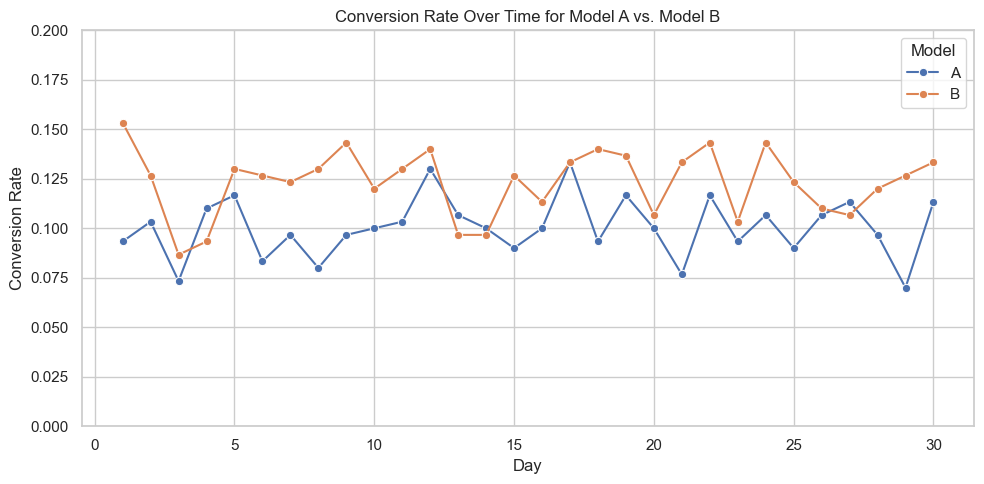

In [7]:

# Line plot of conversion rate over time
# Plot daily conversion rates
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="Day", y="ConversionRate", hue="Model", marker="o")
plt.title("Conversion Rate Over Time for Model A vs. Model B")
plt.ylim(0, 0.2)
plt.ylabel("Conversion Rate")
plt.xlabel("Day")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


### Bayesian A/B Testing

This approach gives probability distributions over conversion rates and helps answer: 

"What's the probability B is better than A?"

---

## Step 3️: Frequentist Analysis (Z-test)

We use a Z-test for proportions to determine if the observed difference in conversion rates is statistically significant.

Steps involved:

Aggregate total users and conversions for both models.

Use proportions_ztest from statsmodels to compute:

**Z-statistic**: how far apart the two proportions are.

**P-value**: the probability of observing such a difference by chance.

A small p-value (e.g., < 0.05) suggests a significant difference.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import pandas as pd
import seaborn as sns


# Frequentist Comparison (Z-test)

conv_a = df[df.Model == 'A'].Conversions.sum()
users_a = df[df.Model == 'A'].Users.sum()
conv_b = df[df.Model == 'B'].Conversions.sum()
users_b = df[df.Model == 'B'].Users.sum()

count = np.array([conv_a, conv_b])
nobs = np.array([users_a, users_b])

stat, pval = proportions_ztest(count, nobs)
print(f"Z-statistic: {stat:.4f}, P-value: {pval:.4f}")


Z-statistic: -4.8730, P-value: 0.0000


## Step 4️: Bayesian A/B Testing using Beta Distributions (TensorFlow-Compatible)

This section demonstrates a Bayesian approach to A/B testing using only `NumPy`, making it lightweight and compatible with TensorFlow environments (no need for PyMC or other probabilistic frameworks).

### Steps Explained

1. **Define Prior Belief**  
   We start with a uniform prior Beta(1, 1) for both models A and B. This reflects no strong initial belief about the conversion rates.

2. **Compute Posterior Parameters**  
   After observing conversions and user counts, we update our priors to posteriors:
   - Posterior for A:  
     `Beta(conv_a + 1, users_a - conv_a + 1)`
   - Posterior for B:  
     `Beta(conv_b + 1, users_b - conv_b + 1)`

3. **Sample from Posteriors**  
   We draw 5,000 samples from each posterior distribution to simulate potential conversion rates.

4. **Compare Models**  
   - **Probability B > A**: We calculate how often samples from model B are greater than those from model A.
   - **Lift**: The relative improvement of B over A, computed as:  
     `((samples_b - samples_a) / samples_a) * 100`

5. **Visualize Posterior Distributions**  
   We plot histograms of the sampled conversion rates for both A and B to visually inspect their distributions.

### Outputs

- **Probability that B is better than A**
- **Expected lift (%) from B over A**
- **Histogram plot of posterior distributions**

This approach offers a simple and intuitive way to run Bayesian A/B tests using TensorFlow-compatible tools.


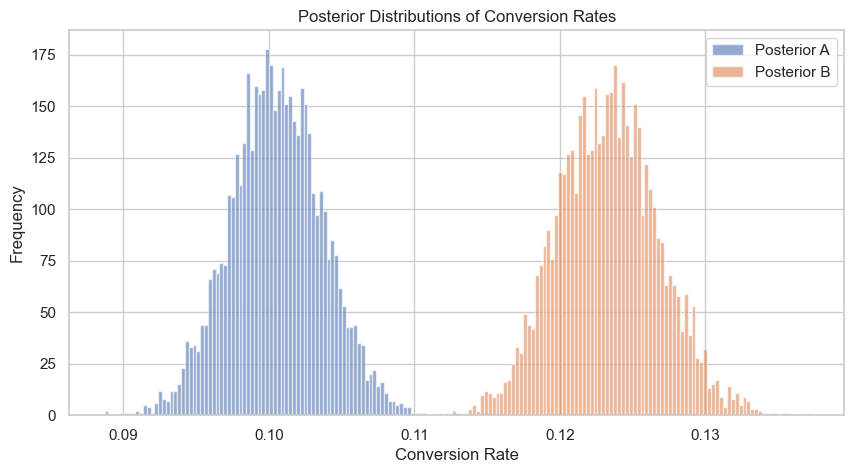

Probability B > A: 1.0000
Mean expected lift of B over A: 22.79%


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Prior parameters
alpha_prior = 1
beta_prior = 1

# Posterior parameters for Beta distribution
posterior_a_alpha = conv_a + alpha_prior
posterior_a_beta = users_a - conv_a + beta_prior
posterior_b_alpha = conv_b + alpha_prior
posterior_b_beta = users_b - conv_b + beta_prior

# Sample from posterior distributions
n_samples = 5000
samples_a = np.random.beta(posterior_a_alpha, posterior_a_beta, n_samples)
samples_b = np.random.beta(posterior_b_alpha, posterior_b_beta, n_samples)

# Compute probability that B is better than A
prob_b_better = np.mean(samples_b > samples_a)
lift = ((samples_b - samples_a) / samples_a) * 100

# Plot posterior distributions
plt.figure(figsize=(10, 5))
plt.hist(samples_a, bins=100, alpha=0.6, label='Posterior A')
plt.hist(samples_b, bins=100, alpha=0.6, label='Posterior B')
plt.title("Posterior Distributions of Conversion Rates")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# Print results
print(f"Probability B > A: {prob_b_better:.4f}")
print(f"Mean expected lift of B over A: {np.mean(lift):.2f}%")


## Step 4️: Bayesian Inference with PyMC

We model the conversion rate for each variant as a Beta distribution, which is a conjugate prior for a binomial likelihood.

Steps:

Define prior distributions: Beta(1, 1) for both A and B.

Observe conversion counts with Binomial likelihoods.

Use pm.sample to draw samples from the posterior distributions of p_A and p_B.

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Initializing NUTS using jitter+adapt_diag...
C:\Users\india\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytensor\tensor\rewriting\elemwise.py:1011: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_A, p_B]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 29 seconds.


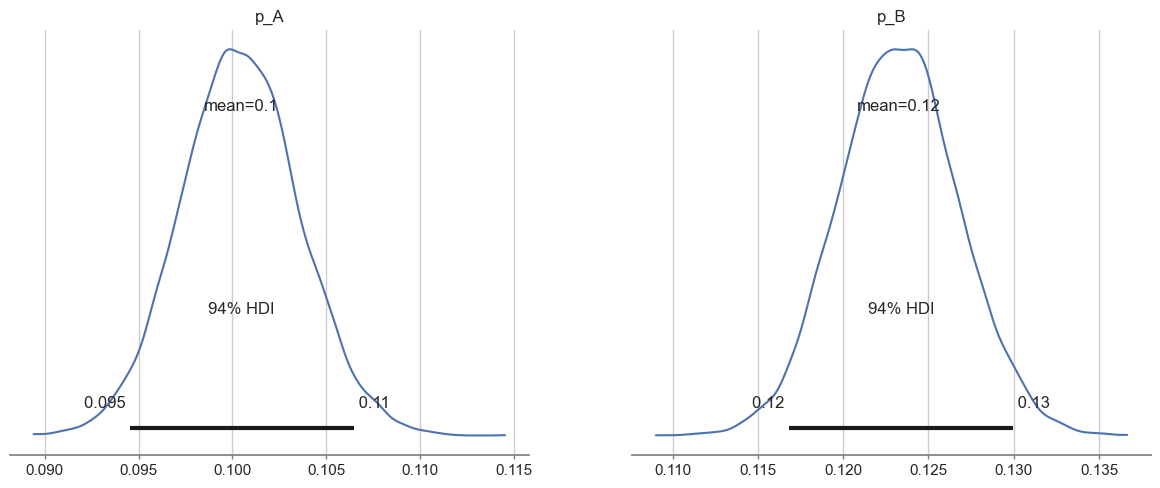

In [10]:
# Bayesian A/B Testing with pyMC

import pymc as pm
import arviz as az
with pm.Model() as model:
    p_A = pm.Beta('p_A', alpha=1, beta=1)
    p_B = pm.Beta('p_B', alpha=1, beta=1)

    obs_A = pm.Binomial('obs_A', n=users_a, p=p_A, observed=conv_a)
    obs_B = pm.Binomial('obs_B', n=users_b, p=p_B, observed=conv_b)

    trace = pm.sample(5000, return_inferencedata=True, progressbar=True)


# Plot posteriors
az.plot_posterior(trace, var_names=["p_A", "p_B"])
plt.show()


| Feature                          | Script 1 (NumPy)                                 | Script 2 (PyMC)                                |
|----------------------------------|--------------------------------------------------|------------------------------------------------|
| **Library**                      | NumPy, Matplotlib                                | PyMC, ArviZ                                    |
| **Method**                       | Analytical Beta posterior (conjugate prior)      | MCMC sampling (NUTS or HMC)                    |
| **Flexibility**                  | Limited (only works with simple Beta-Binomial)   | High (can model complex relationships)         |
| **Sampling Approach**            | Direct Beta sampling                             | MCMC-based sampling                            |
| **Diagnostics**                  | None                                             | Full (e.g., trace plots, ESS, R-hat)           |
| **Visualization**                | Simple histograms                                | Detailed posterior plots with intervals        |
| **Performance**                  | Very fast                                        | Slower due to sampling                         |


## Step 5️: Plot Posterior Distributions

Using ArviZ, we plot the posterior distributions of p_A and p_B. These represent our updated beliefs about each model’s conversion rate after seeing the data.

In [11]:
# Already computed earlier:
# samples_a = np.random.beta(posterior_a_alpha, posterior_a_beta, n_samples)
# samples_b = np.random.beta(posterior_b_alpha, posterior_b_beta, n_samples)

# Compute probability that B is better than A
prob_b_better = np.mean(samples_b > samples_a)
print(f"Probability Model B is better than Model A: {prob_b_better:.2%}")


Probability Model B is better than Model A: 100.00%


## Step 6️: Compute Probability that B > A

From the posterior samples:

Estimate the probability that Model B has a higher conversion rate than Model A.

This gives us a direct answer to the question: "What is the probability that B is better than A?"

#### Multi-Metric Evaluation / Uplift Modeling  (Causal Inference)



In [12]:
# Simulate click-through and purchase data
click_rate_a, click_rate_b = 0.15, 0.18
purchase_rate_a, purchase_rate_b = 0.05, 0.06

clicks_a = np.random.binomial(users_a, click_rate_a)
clicks_b = np.random.binomial(users_b, click_rate_b)

purchases_a = np.random.binomial(users_a, purchase_rate_a)
purchases_b = np.random.binomial(users_b, purchase_rate_b)

print("Model A - CTR:", clicks_a / users_a, "| Purchases:", purchases_a / users_a)
print("Model B - CTR:", clicks_b / users_b, "| Purchases:", purchases_b / users_b)

# Uplift
print("Uplift in CTR: {:.2%}".format((clicks_b / users_b - clicks_a / users_a)))
print("Uplift in Purchase Rate: {:.2%}".format((purchases_b / users_b - purchases_a / users_a)))


Model A - CTR: 0.14833333333333334 | Purchases: 0.04577777777777778
Model B - CTR: 0.17344444444444446 | Purchases: 0.060333333333333336
Uplift in CTR: 2.51%
Uplift in Purchase Rate: 1.46%


## Step 7️: Multi-Metric Evaluation

In real-world A/B tests, conversion rate is often not the only metric that matters. Other KPIs might include:

1. Revenue per user

2. Time spent on site

3. Number of sessions

4. Number of purchases

In [13]:
# Simulate additional metrics
df["Revenue"] = df["Conversions"] * np.where(df["Model"] == "A", 20, 22)  # assume B has higher value per conv
df["SessionTime"] = np.random.normal(loc=np.where(df["Model"] == "A", 180, 190), scale=15)

# Compare averages
df.groupby("Model")[["ConversionRate", "Revenue", "SessionTime"]].mean()


,ConversionRate,Revenue,SessionTime
Model,,,
A,0.100333,602.000000,182.884431
B,0.123222,813.266667,193.879612


Step 8️: Uplift Modeling (Causal Impact)
Uplift modeling estimates individual-level treatment effects: Which users are more likely to convert because they saw Model B?

Instead of just answering "Is B better than A?", uplift tells you "For whom is B better than A?", unlocking personalized targeting and causal insights.
use libraries: econml (by Microsoft), scikit-uplift, causalml

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklift.models import ClassTransformation
from sklift.metrics import uplift_at_k

# Create synthetic binary feature matrix
df["feature1"] = np.random.rand(len(df))
df["feature2"] = np.random.randint(0, 2, len(df))

# Prepare treatment/control labels and features
df["treatment"] = (df["Model"] == "B").astype(int)
# Ensure 'converted' contains both 0 and 1 values
df["converted"] = (df["Conversions"] > df["Conversions"].median()).astype(int)

X = df[["feature1", "feature2"]]
y = df["converted"]
treatment = df["treatment"]

# Uplift Model
uplift_model = ClassTransformation(RandomForestClassifier())
uplift_model.fit(X, y, treatment)

# Score uplift
uplift_scores = uplift_model.predict(X)
print("Uplift at 30%:", uplift_at_k(y, uplift_scores, treatment, strategy='overall', k=0.3))


Uplift at 30%: 1.0


In [15]:
import numpy as np
import sys
np.__version__ 
#if np.__version__ < '1.24':
#    print("Warning: Numpy version is lower than 1.24. Some features might not work.")
#    # Implement alternative logic here


'2.2.5'

# Interactive A/B Testing Dashboard

## Overview

This repository provides an interactive A/B testing dashboard built with **Streamlit**. The dashboard allows you to simulate or use real A/B testing data, perform statistical analysis (Frequentist and Bayesian), and visualize conversion rates and other business metrics over time. It aims to help businesses and data analysts make data-driven decisions on which model (or variant) performs best.

## Features

- **Simulate Data**: Create synthetic A/B testing data by defining user count, conversion rates, and duration.
- **Predefined Datasets**: Select from predefined datasets for easy testing and analysis.
- **Summary Metrics**: View total users, conversions, and conversion rates for each model.
- **Conversion Rate Over Time**: Visualize how the conversion rate evolves day-by-day for each model.
- **Statistical Testing**:
  - **Z-Test**: A Frequentist method to determine if the difference between conversion rates is statistically significant.
  - **Bayesian Inference**: Use a Bayesian approach to calculate the posterior distributions of the conversion rates and estimate the probability that one model outperforms the other.
- **Multi-Metric Evaluation**: Evaluate models based on multiple metrics, including revenue and session time, in addition to conversion rate.
- **Interactive Visualization**: View the results in an interactive dashboard that allows real-time updates based on user inputs.

## Usage

### 1. Data Setup
- **Simulate Data**: You can simulate A/B test data by adjusting settings such as the number of users per day, conversion rates for both models (A and B), and the number of days the test runs.
- **Predefined Datasets**: Select from a set of predefined datasets that simulate typical A/B testing scenarios.

### 2. Summary Metrics
- View key metrics such as total users, total conversions, conversion rates, and the conversion rate difference (delta) between Model A and Model B.

### 3. Conversion Rate Over Time
- This section visualizes how the conversion rate changes over time (day-by-day) for both models. It helps identify trends or fluctuations in the data.

### 4. Statistical Analysis
- **Frequentist Z-Test**: A statistical test to determine if the difference between Model A and Model B's conversion rates is statistically significant.
- **Bayesian Inference**: Bayesian inference is used to estimate the posterior distributions of the conversion rates for both models. This allows us to calculate the probability that Model B performs better than Model A.

### 5. Multi-Metric Evaluation
- The dashboard also evaluates the models on additional business metrics, such as revenue and session time. This helps to better understand the overall impact of each model beyond conversion rate.

### 6. Conclusion
- The app provides a final conclusion based on the analyses, helping the user make an informed decision on which model to choose.


## Key Concepts

### 1. A/B Testing
A/B testing is a randomized experiment comparing two versions of a variable to determine which one performs better. In this case, the "models" represent different versions of an element (e.g., a webpage design, an ad campaign).

### 2. Frequentist Z-Test
A Z-test compares the difference between two proportions (in this case, the conversion rates of the two models) and tells us whether this difference is statistically significant. If the p-value is below a threshold (typically 0.05), we reject the null hypothesis and conclude that there is a significant difference between the two models.

### 3. Bayesian Inference
Bayesian inference is a statistical method that updates the probability of a hypothesis (in this case, the conversion rate of each model) based on prior knowledge and new data. We use it to calculate the posterior distributions of the conversion rates for Model A and Model B.

### 4. Multi-Metric Evaluation
In addition to conversion rate, models are evaluated based on other business metrics, such as revenue and session time. This helps provide a more complete view of the models' performance.


## Dependencies

The following libraries are required to run the application:

- **Streamlit**: For creating the interactive web app.
- **Pandas**: For data manipulation and analysis.
- **Numpy**: For numerical operations.
- **Seaborn & Matplotlib**: For data visualization.
- **SciPy**: For statistical tests, including the Z-test.
- **PyMC**: For Bayesian inference and posterior sampling.
- **Arviz**: For visualizing Bayesian inference results.

